In [1]:
import numpy as np
import matplotlib.pyplot as plt

import limpy.lcp as ll

In [2]:
# Plot SFR with halomass in redshift range 0 to 8. 
# You can files using "read_sfr" function. or you can use inbuild "plot_sfr_mhalo" directly
# you may need to change the plotting parameters such as xlim, ylim, color etc....

In [3]:
log_mhalo=11  # halo mass in log scale, units are in M_sun
sfr=ll.mhalo_to_sfr(log_mhalo)

/opt/anaconda2/lib/python2.7/site-packages/matplotlib/axes/_base.py:3477: UserWarning: Attempted to set non-positive ylimits for log-scale axis; invalid limits will be ignored.
  'Attempted to set non-positive ylimits for log-scale axis; '


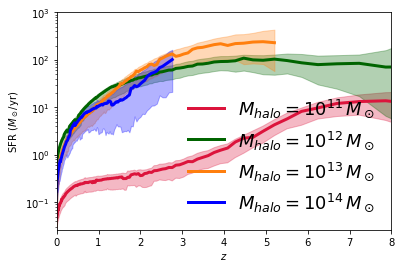

In [4]:
#plot
log_mhalo=[11,12,13,14]
ll.plot_sfr_mhalo(log_mhalo)

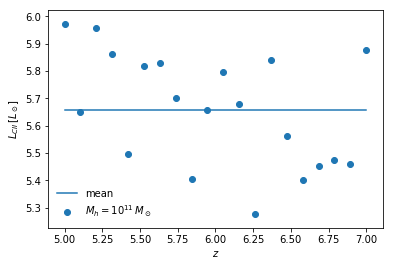

In [5]:
# plot luminosity of CII line at z=6 for the halo mass 1e11. 
# PLEASE NOTE that the result will change if you run the 
#same code again as we have used the scattered relation between SFR and CII luminosity
z=np.linspace(5,7,num=20)
mh=11
lc2=ll.mhalo_to_lcp(z,mh)
plt.scatter(z,lc2,label=r"$M_{h}=10^{11}\, M_\odot$")
plt.plot(z, np.mean(lc2)*np.ones(len(z)),label="mean")

plt.xlabel("$z$")
plt.ylabel(r"$L_{CII}\,[L_\odot]$")
plt.legend(loc=0,frameon=False)

Text(0,0.5,'$\\log(L_{CII})\\,\\,[L_\\odot]$')

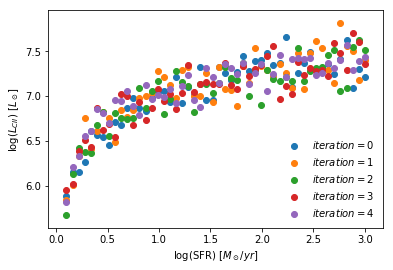

In [6]:
# Make same plot for 5 times at z=6, for different star formation rate to check the Gaussian scatter in L_{CII}
z=7 #redshift
sfr=np.linspace(0.1,3,num=50) #SFR rate
num_of_iteration=5

for i in range(num_of_iteration):
    lc2=ll.sfr_to_lcp_scatter(z, sfr)
    
    #scatter lc2 points
    plt.scatter(sfr,lc2,label=r"$iteration=%d$" %(i))
    plt.legend(loc=0,frameon=False)
    
plt.xlabel(r"$\log(\mathrm{SFR})\,\,[M_\odot/yr]$")
plt.ylabel(r"$\log(L_{CII})\,\,[L_\odot]$")
#plt.ylim(4.0,9)



Minimum halo mass: 1406342000.0
Maximum halo mass: 3168829000000.0
r_lcp [6.89057146 5.44328438 5.69868572 ... 0.         0.         0.        ]


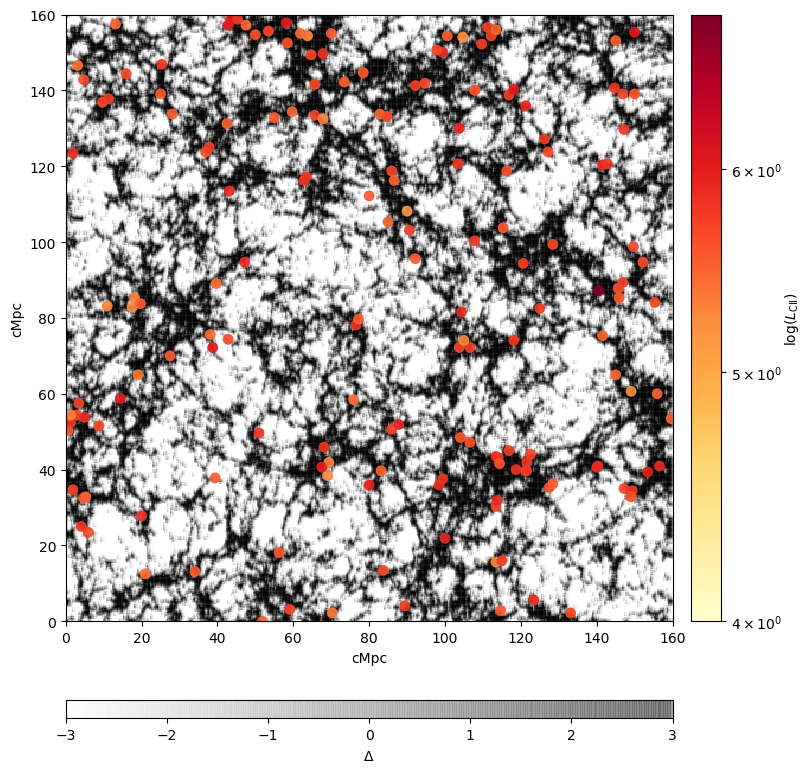

In [7]:
"""
plot_slice module can make slice plots for density.

This function takes few inputs as described below. 

Set "True" for any of these arguments at a time: density_plot,
           halo_overplot, and plot_lines.
"""

boxsize=160  # Size of the box in comoving Mpc (cMpc)
ngrid= 512  # number of grids along the box axis
nproj=10    # no of cells to project
halo_redshift=7.02 # redshift of halos, (Note: at this point it is not used in the function)


#It can read halos and density only from the redshift information but now, lets just do it for one redshift 
# by manually providng the files

#location of density file
dens_file='/Users/anirbanroy/Documents/line-intensity/updated_smoothed_deltax_z005.85_512_160Mpc' 

#location of halo catalogue file

halocat_file='/Users/anirbanroy/Documents/line-intensity/halos_z5.85_512_160Mpc'


#plot only the density slice
ll.plot_slice(boxsize, ngrid, nproj, dens_file, halocat_file,halo_redshift,halo_cutoff_mass_log=9, density_plot=False,
           halo_overplot=False ,plot_lines=True)

Minimum halo mass: 1406342000.0
Maximum halo mass: 3168829000000.0


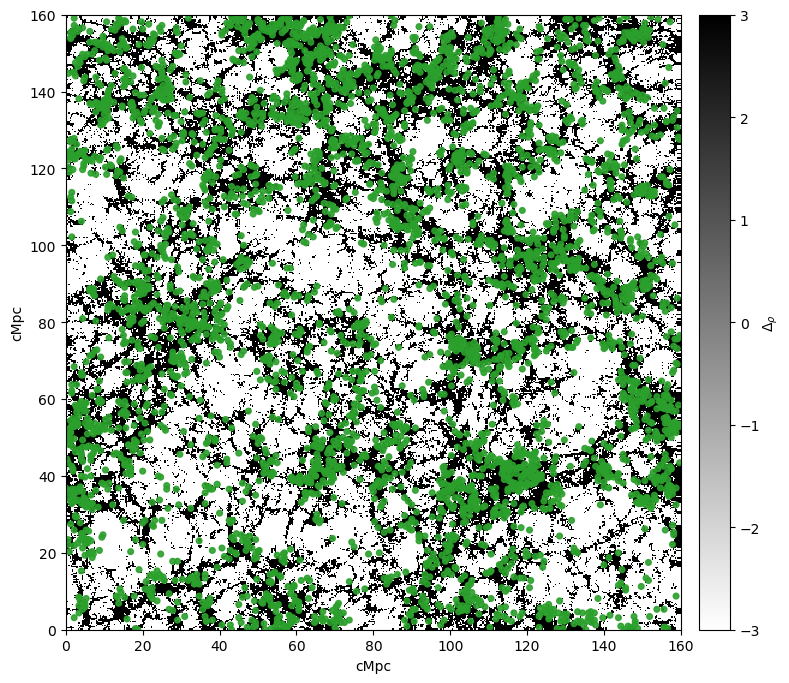

In [8]:
# overplot halos on the density distribution
ll.plot_slice(boxsize, ngrid, nproj, dens_file, halocat_file,halo_redshift,halo_cutoff_mass_log=9, density_plot=False,
           halo_overplot=True ,plot_lines=False)

Minimum halo mass: 1406342000.0
Maximum halo mass: 3168829000000.0
r_lcp [6.82457562 5.87172937 5.79750436 ... 0.         0.         0.        ]


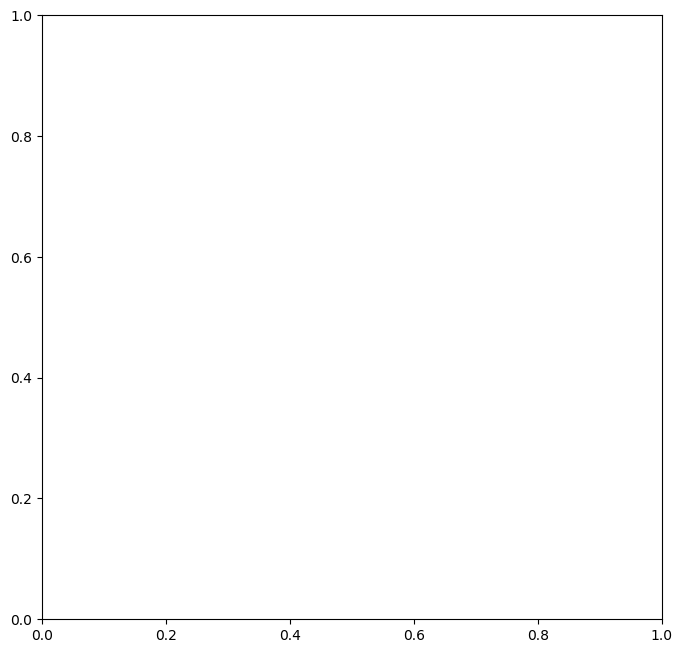

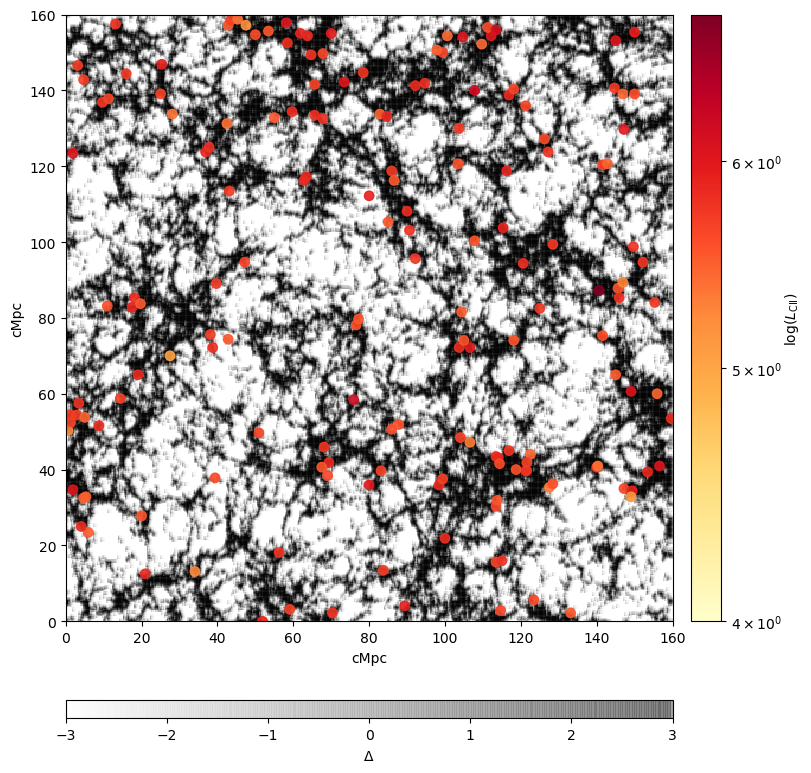

In [9]:
# overplot CII line luminosities on the density distribution
ll.plot_slice(boxsize, ngrid, nproj, dens_file, halocat_file,halo_redshift,halo_cutoff_mass_log=9, density_plot=False,
           halo_overplot=False ,plot_lines=True)